In [1]:
import polars as pl
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from matplotlib.patches import Patch
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
benchmark_metrics = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics_benchmark_bigger_complexes.parquet")
benchmark_best_cp  = benchmark_metrics.sort(pl.col("CF_confidence"), descending=True).group_by("complex_ac").first()
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)

In [3]:
benchmark_best_cp_bigger.write_parquet(PRJ_ROOT/ "tmp/benchmark_best_cp_bigger.parquet")

In [4]:
print(PRJ_ROOT/ "tmp/benchmark_best_cp_bigger.parquet")

/cluster/project/beltrao/kdammer/master_thesis/tmp/benchmark_best_cp_bigger.parquet


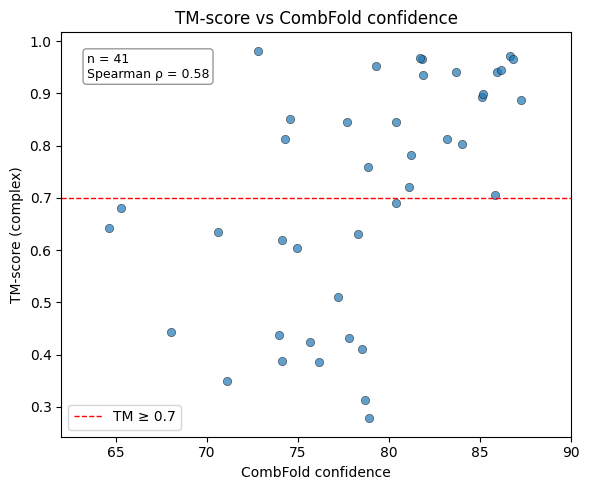

In [6]:
#scatter plot of Tm score over the confidence
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    benchmark_best_cp_bigger["CF_confidence"],
    benchmark_best_cp_bigger["usalign_cpx_tm_score"],
    alpha=0.7, edgecolors="k", linewidths=0.4
)
ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
ax.set_xlabel("CombFold confidence")
ax.set_ylabel("TM-score (complex)")
ax.set_title("TM-score vs CombFold confidence")
ax.legend()

x = benchmark_best_cp_bigger["CF_confidence"].to_numpy()
y = benchmark_best_cp_bigger["usalign_cpx_tm_score"].to_numpy()
n = len(x)
spearman_r, spearman_p = stats.spearmanr(x, y)

ax.annotate(
    f"n = {n}\nSpearman ρ = {spearman_r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
)
plt.xlim(62, 90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1460736/2696764227.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


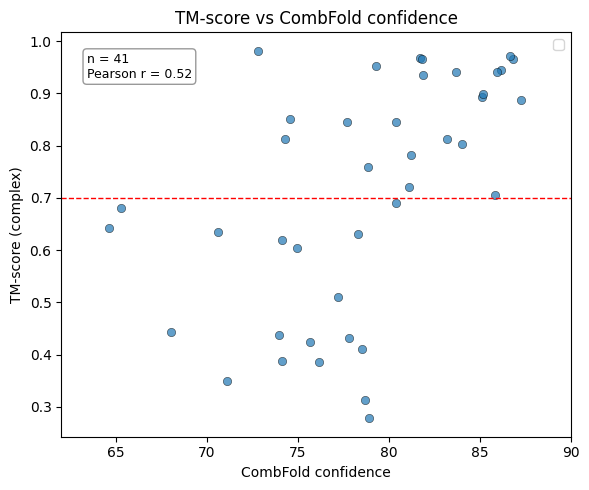

In [6]:
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    benchmark_best_cp_bigger["CF_confidence"],
    benchmark_best_cp_bigger["usalign_cpx_tm_score"],
    alpha=0.7, edgecolors="k", linewidths=0.4
)
ax.axhline(0.7, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("CombFold confidence")
ax.set_ylabel("TM-score (complex)")
ax.set_title("TM-score vs CombFold confidence")
ax.legend()

x = benchmark_best_cp_bigger["CF_confidence"].to_numpy()
y = benchmark_best_cp_bigger["usalign_cpx_tm_score"].to_numpy()
n = len(x)
pearson_r, pearson_p = stats.pearsonr(x, y)

ax.annotate(
    f"n = {n}\nPearson r = {pearson_r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
)
plt.xlim(62, 90)
plt.tight_layout()
plt.show()

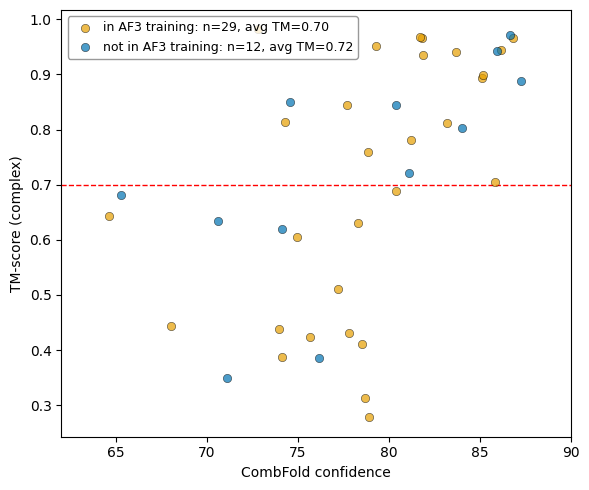

In [14]:
deposition_dates = pl.read_csv(
    "/cluster/project/beltrao/kdammer/master_thesis/data/complete_complex_pdb_mapping_v2/exact_pdb_match_deposition_dates.csv"
).select(["complex_ac", "Deposited before 2021-09-30"])

df = (
    benchmark_best_cp_bigger
    .join(deposition_dates, on="complex_ac", how="left")
)

fig, ax = plt.subplots(figsize=(6, 5))

colors = {"in_training": "#E69F00", "post_training": "#0072B2"}

for flag, color in [(True, colors["in_training"]), (False, colors["post_training"])]:
    sub = df.filter(pl.col("Deposited before 2021-09-30") == flag)
    n = len(sub)
    mean_tm = sub["usalign_cpx_tm_score"].mean()
    label = f"{'in' if flag else 'not in'} AF3 training: n={n}, avg TM={mean_tm:.2f}"
    ax.scatter(
        sub["CF_confidence"],
        sub["usalign_cpx_tm_score"],
        alpha=0.7, edgecolors="k", linewidths=0.4,
        color=color, zorder=3, label=label
    )

ax.axhline(0.7, color="red", linestyle="--", linewidth=1)

ax.set_xlabel("CombFold confidence")
ax.set_ylabel("TM-score (complex)")
#ax.set_title("TM-score vs CombFold confidence\n(color = AF3 training data status)")

ax.legend(
    fontsize=9, loc="upper left",
    framealpha=0.8, edgecolor="gray",
    handletextpad=0.4
)

plt.xlim(62, 90)
plt.tight_layout()
plt.show()

In [8]:
df.group_by("Deposited before 2021-09-30").agg(
    pl.col("usalign_cpx_tm_score").median().alias("median_tm"),
    pl.col("usalign_cpx_tm_score").mean().alias("mean_tm"),
    pl.len().alias("n"),
).sort("Deposited before 2021-09-30", descending=True)

Deposited before 2021-09-30,median_tm,mean_tm,n
bool,f64,f64,u32
true,0.75965,0.702322,29
false,0.76227,0.724286,12


In [4]:
# how many of the complexes od i keep, hoq many have  tM over 0.7  and waht is the fraction
# 2. For each confidence threshold: n complexes kept, n with TM ≥ 0.7, fraction
thresholds = np.arange(0, 100, 5)

rows = []
for t in thresholds:
    kept = benchmark_best_cp_bigger.filter(pl.col("CF_confidence") >= t)
    n_kept = len(kept)
    n_good = kept.filter(pl.col("usalign_cpx_tm_score") >= 0.7).height
    rows.append({"threshold": t, "n_kept": n_kept, "n_tm_good": n_good, "fraction": n_good / n_kept if n_kept > 0 else None})

summary = pl.DataFrame(rows)
print(summary)

shape: (20, 4)
┌───────────┬────────┬───────────┬──────────┐
│ threshold ┆ n_kept ┆ n_tm_good ┆ fraction │
│ ---       ┆ ---    ┆ ---       ┆ ---      │
│ i64       ┆ i64    ┆ i64       ┆ f64      │
╞═══════════╪════════╪═══════════╪══════════╡
│ 0         ┆ 41     ┆ 23        ┆ 0.560976 │
│ 5         ┆ 41     ┆ 23        ┆ 0.560976 │
│ 10        ┆ 41     ┆ 23        ┆ 0.560976 │
│ 15        ┆ 41     ┆ 23        ┆ 0.560976 │
│ 20        ┆ 41     ┆ 23        ┆ 0.560976 │
│ …         ┆ …      ┆ …         ┆ …        │
│ 75        ┆ 29     ┆ 20        ┆ 0.689655 │
│ 80        ┆ 18     ┆ 17        ┆ 0.944444 │
│ 85        ┆ 8      ┆ 8         ┆ 1.0      │
│ 90        ┆ 0      ┆ 0         ┆ null     │
│ 95        ┆ 0      ┆ 0         ┆ null     │
└───────────┴────────┴───────────┴──────────┘


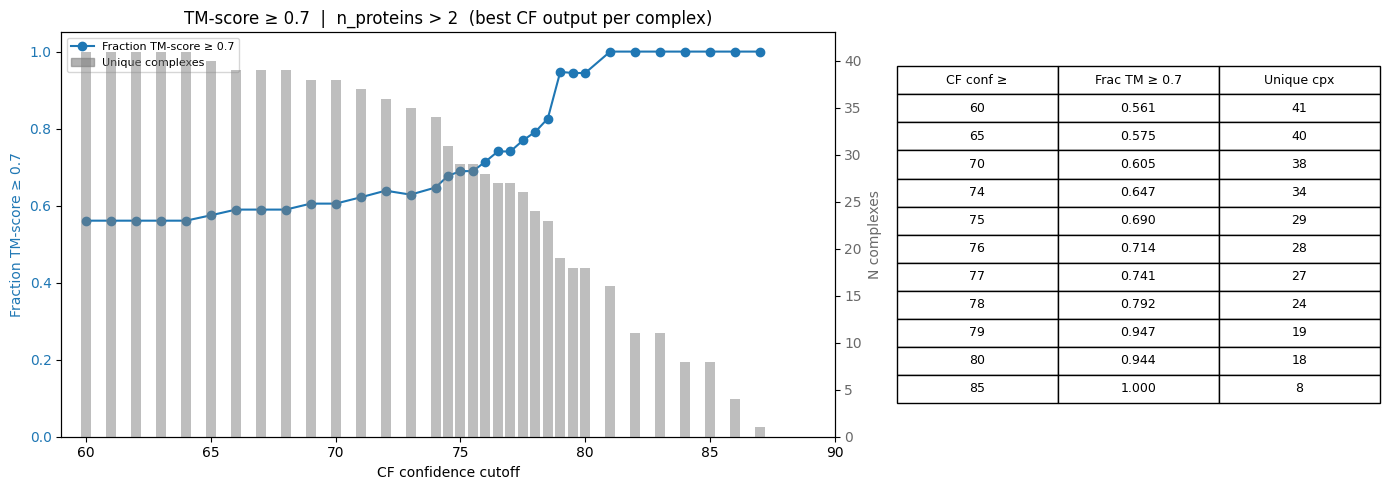

In [7]:
TM_TARGET = 0.7
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)

def precision_vs_cutoff(df, metric_col, target, higher_is_better=True,
                        thresholds=np.arange(60, 90, 1)):
    rows = []
    for t in thresholds:
        sub = df.filter(pl.col('CF_confidence') >= t)
        n_out = len(sub)
        n_cpx = sub['complex_ac'].n_unique() if n_out > 0 else 0
        if n_out > 0:
            prec = float((sub[metric_col] >= target if higher_is_better
                          else sub[metric_col] <= target).mean())
        else:
            prec = None
        rows.append((t, prec, n_cpx, n_out))
    return rows

def add_plot(ax1, rows, ylabel, color):
    thresholds_v, precisions, n_complexes_v, n_outputs_v = zip(*rows)
    ax1.plot(thresholds_v, precisions, marker='o', color=color)
    ax1.set_xlabel('CF confidence cutoff')
    ax1.set_ylabel(ylabel, color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.05)
    ax1.set_xlim(59, max(thresholds_v) + 1)
    ax2 = ax1.twinx()
    ax2.bar(thresholds_v, n_complexes_v, alpha=0.5, color='tab:grey', width=0.4)
    ax2.set_ylabel('N complexes', color='dimgray')
    ax2.tick_params(axis='y', labelcolor='dimgray')
    ax1.legend(handles=[
        plt.Line2D([0],[0], marker='o', color=color, label=ylabel),
        Patch(color='tab:grey', alpha=0.6, label='Unique complexes'),
    ], loc='upper left', fontsize=8)

def add_table(ax, rows, frac_label):
    lookup = {r[0]: r for r in rows}  # float keys
    cols = ['CF conf ≥', frac_label, 'Unique cpx']
    cells = []
    for t in [60, 65, 70, 74, 75, 76, 77, 78, 79, 80, 85]:
        r = lookup.get(t) or lookup.get(float(t))
        if r:
            prec = f'{r[1]:.3f}' if r[1] is not None else 'nan'
            cells.append([str(t), prec, str(r[2])])
    ax.axis('off')
    tab = ax.table(cellText=cells, colLabels=cols, cellLoc='center', loc='center')
    tab.auto_set_font_size(False)
    tab.set_fontsize(9)
    tab.scale(1, 1.6)

thresholds = np.concatenate([
    np.arange(60, 74, 1),
    np.arange(74, 80, 0.5),
    np.arange(80, 90, 1),
])

rows_tm = precision_vs_cutoff(benchmark_best_cp_bigger, 'usalign_cpx_tm_score', TM_TARGET,
                               thresholds=thresholds)

fig, (ax_plot, ax_tab) = plt.subplots(1, 2, figsize=(14, 5),
                                       gridspec_kw={'width_ratios': [1.6, 1]})
add_plot(ax_plot, rows_tm, f'Fraction TM-score ≥ {TM_TARGET}', 'tab:blue')
ax_plot.set_title(f'TM-score ≥ {TM_TARGET}  |  n_proteins > 2  (best CF output per complex)')
add_table(ax_tab, rows_tm, f'Frac TM ≥ {TM_TARGET}')
fig.tight_layout()
plt.show()

stacked barplot

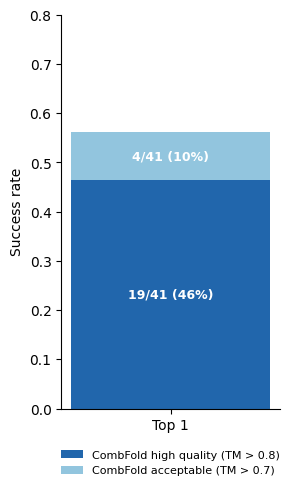

In [8]:
barplot_stacked_df = benchmark_best_cp_bigger.select(["complex_ac","usalign_cpx_tm_score"]) 
BLUE  = "#2166AC"   # high quality — bottom
LBLUE = "#92C5DE"   # acceptable — top

df = barplot_stacked_df
n   = df.height
hq  = (df["usalign_cpx_tm_score"] > 0.8).sum()
acc = (df["usalign_cpx_tm_score"] > 0.7).sum() - hq

hq_frac  = hq  / n
acc_frac = acc / n

fig, ax = plt.subplots(figsize=(3, 5))

ax.bar([0], [hq_frac],                    width=0.5, color=BLUE,  label="CombFold high quality (TM > 0.8)")
ax.bar([0], [acc_frac], bottom=[hq_frac], width=0.5, color=LBLUE, label="CombFold acceptable (TM > 0.7)")

ax.text(0, hq_frac / 2,             f"{hq}/{n} ({hq_frac:.0%})",   ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.text(0, hq_frac + acc_frac / 2,  f"{acc}/{n} ({acc_frac:.0%})", ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax.set_xticks([0])
ax.set_xticklabels(["Top 1"])
ax.set_ylabel("Success rate")
ax.set_ylim(0, 0.8)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    frameon=False,
    fontsize=8,
    ncol=1,
)

plt.tight_layout()

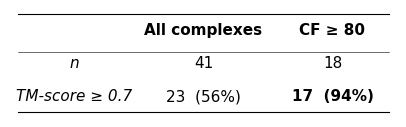

In [16]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import polars as pl
df = benchmark_best_cp_bigger

cf = df['CF_confidence'].to_numpy()
tm = df['usalign_cpx_tm_score'].to_numpy()

n_all       = len(cf)
n_all_good  = (tm >= 0.7).sum()
n_cf80      = (cf >= 80).sum()
n_cf80_good = ((cf >= 80) & (tm >= 0.7)).sum()

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

col_labels = ['', 'All complexes', 'CF ≥ 80']
rows = [
    ['n',              str(n_all), str(n_cf80)],
    ['TM-score ≥ 0.7', f'{n_all_good}  ({100*n_all_good//n_all}%)', f'{n_cf80_good}  ({100*n_cf80_good//n_cf80}%)'],
]

fig, ax = plt.subplots(figsize=(4.2, 1.4))
ax.axis('off')

tbl = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)

for (i, j), cell in tbl.get_celld().items():
    cell.set_facecolor('none')
    cell.set_edgecolor('none')

for j in range(3):
    tbl[0, j].get_text().set_fontweight('bold')
for i in range(1, 3):
    tbl[i, 0].get_text().set_fontstyle('italic')
tbl[2, 2].get_text().set_fontweight('bold')

for y, lw in [(0.96, 0.8), (0.61, 0.4), (0.05, 0.8)]:
    ax.add_line(mlines.Line2D([0.02, 0.98], [y, y], transform=ax.transAxes,
                              color='black', linewidth=lw))
plt.tight_layout()


## Same analysis with more elaborate benchmark

In [ ]:
import polars as pl
from pathlib import Path
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from procompa.helpers import clean_identifiers
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

benchmark_structure_similarity = pl.read_parquet(data_dir / "Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")
benchmark_structure_similarity = clean_identifiers(benchmark_structure_similarity, "identifiers")
benchmark_structure_similarity = benchmark_structure_similarity.with_columns(
    pl.col("CP_stochiometry").map_elements(lambda s: any(v > 1 for v in json.loads(s).values()), return_dtype=pl.Boolean).alias("interesting_stoichiometry")
)

# add Cf output for eahc row
conf = {}
for d in {Path(p).parent for p in benchmark_structure_similarity["combfold_output_path"]}:
    conf.update(dict(line.split() for line in open(d / "confidence.txt")))

benchmark_metrics = benchmark_structure_similarity.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf[p]), return_dtype=pl.Float64).alias("CF_confidence"))
benchmark_best_cp  = benchmark_metrics.sort(pl.col("CF_confidence"), descending=True).group_by("complex_ac").first()
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)

## Which pairs were used for assembling

Extract pairs used in the highest-confidence CombFold assembly
For each complex:
1. PDB filename (`output_clustered_N.pdb`) → N is the 0-based index into `output_clustered.res`
2. Line N of `output_clustered.res` → read `foldSteps: (child,parent)-score ...`
3. Map chain indices → protein names using `chain.list` (line i = index i)
Here we do the same thing systematically for all rows in the dataframe.
The `combfold_output_path` column already encodes step 1 (highest-confidence PDB
was selected upstream), so we start directly from step 2.


In [ ]:
"""
has same output as cell below, just used to double check
import re
import warnings
import polars as pl

benchmark_metrics = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics_benchmark_bigger_complexes.parquet")
benchmark_best_cp  = benchmark_metrics.sort(pl.col("CF_confidence"), descending=True).group_by("complex_ac").first()
benchmark_best_cp_bigger = benchmark_best_cp.filter(pl.col("n_proteins") > 2)
df = benchmark_best_cp_bigger
print(f"{len(df)} complexes loaded")


# Step 2: from combfold_output_path, derive the paths to output_clustered.res
# and chain.list, and the 0-based line index into output_clustered.res.
# Directory layout (from run_on_pdbs.py):
#   <pool_output_dir>/
#     _unified_representation/assembly_output/
#       chain.list
#       output_clustered.res
#     assembled_results/
#       output_clustered_N.pdb   <- combfold_output_path
def derive_paths(combfold_output_path):
    pdb_filename = combfold_output_path.split("/")[-1]

    match = re.search(r"output_clustered_(\d+)\.pdb", pdb_filename)
    assert match, f"unexpected filename: {pdb_filename}"
    pdb_index = int(match.group(1))

    assembled_results_dir = "/".join(combfold_output_path.split("/")[:-1])
    pool_output_dir       = "/".join(assembled_results_dir.split("/")[:-1])
    assembly_output_dir   = pool_output_dir + "/_unified_representation/assembly_output"

    clustered_res_path = assembly_output_dir + "/output_clustered.res"
    chain_list_path    = assembly_output_dir + "/chain.list"

    return clustered_res_path, chain_list_path, pdb_index


# Step 3: read chain.list line by line.
# Line i (0-based) maps chain index i to a protein name.
def read_chain_list(chain_list_path):
    with open(chain_list_path) as f:
        return [
            line.strip().replace(".pdb", "")
            for line in f
            if line.strip()
        ]


# Step 4: read line pdb_index from output_clustered.res and parse the foldSteps.
# Returns only the list of pairs — n_chains comes from the caller via len(chain_list).
def parse_foldsteps(clustered_res_path, pdb_index, chain_list):
    with open(clustered_res_path) as f:
        lines = [l.rstrip("\n") for l in f if l.strip()]

    line = lines[pdb_index]

    fold_match = re.search(r"foldSteps: (.+)$", line)
    assert fold_match, f"no foldSteps in line {pdb_index} of {clustered_res_path}"

    pairs = []
    for child_idx, parent_idx, score in re.findall(
        r"\((\d+),\s*(\d+)\)-([0-9.]+)", fold_match.group(1)
    ):
        child  = chain_list[int(child_idx)]
        parent = chain_list[int(parent_idx)]

        # canonical undirected pair: sort the two UniProt IDs alphabetically
        uniprot_child  = child.split("_")[0]
        uniprot_parent = parent.split("_")[0]
        pair = "_".join(sorted([uniprot_child, uniprot_parent]))

        pairs.append({
            "child":      child,
            "parent":     parent,
            "pair_score": float(score),
            "pair":       pair,
        })

    return pairs


# Run all steps for a single row.
# n_chains comes from len(chain_list), not from parse_foldsteps.
def extract_pairs_for_row(row):
    try:
        res_path, chain_path, pdb_index = derive_paths(row["combfold_output_path"])
        chain_list = read_chain_list(chain_path)
        pairs = parse_foldsteps(res_path, pdb_index, chain_list)
        return pairs, len(chain_list)
    except Exception as e:
        warnings.warn(f"{row['complex_ac']}: {e}")
        return None, None


# Run for all complexes and format pairs as {pair_name: pair_score}
foldstep_records = []
for row in df.iter_rows(named=True):
    pairs, n_chains = extract_pairs_for_row(row)

    # format as {pair_name: pair_score}, e.g. {"P22139_P35718": 87.41, ...}
    # note: if the same pair appears twice (homo-oligomers), the last score wins
    pairs_dict = (
        {p["pair"]: p["pair_score"] for p in pairs}
        if pairs is not None else None
    )

    foldstep_records.append({
        "complex_ac":       row["complex_ac"],
        "foldstep_pairs":   str(pairs_dict) if pairs_dict is not None else None,
        "n_foldstep_pairs": len(pairs_dict) if pairs_dict is not None else None,
        "n_chains":         n_chains,
    })

pairs_df = pl.DataFrame(foldstep_records)
df = df.join(pairs_df, on="complex_ac", how="left")


df.select(["complex_ac", "CF_confidence", "n_chains",
           "n_foldstep_pairs", "foldstep_pairs"]).head(5)
"""

41 complexes loaded


complex_ac,CF_confidence,n_chains,n_foldstep_pairs,foldstep_pairs
str,f64,i64,i64,str
"""CPX-44""",81.8104,7,6,"""{'P57743_Q06406': 82.4818, 'P3…"
"""CPX-112""",78.5124,8,7,"""{'P57743_Q06406': 82.4818, 'P4…"
"""CPX-45""",83.6716,7,6,"""{'P57743_Q06406': 82.4818, 'P4…"
"""CPX-3087""",79.2782,4,3,"""{'P38751_Q12318': 80.5458, 'P3…"
"""CPX-1186""",74.0975,4,3,"""{'P39731_Q12143': 75.7753, 'P3…"


In [7]:
import re
import polars as pl
from pathlib import Path

def get_foldstep_pairs(combfold_output_path: str) -> list[str] | None:
    pdb_path = Path(combfold_output_path)
    m = re.search(r"output_clustered_(\d+)\.pdb$", pdb_path.name)
    if not m:
        return None
    line_idx = int(m.group(1))

    # assembled_results/ -> pool_output/ -> _unified_representation/assembly_output/
    assembly_output_dir = pdb_path.parent.parent / "_unified_representation" / "assembly_output"
    res_path = assembly_output_dir / "output_clustered.res"
    chain_list_path = assembly_output_dir / "chain.list"

    if not res_path.exists() or not chain_list_path.exists():
        print(f"Missing files for {combfold_output_path}")
        return None

    idx_to_uniprot = {
        i: Path(l.strip()).stem.split("_")[0]
        for i, l in enumerate(chain_list_path.read_text().strip().splitlines())
    }

    lines = [l for l in res_path.read_text().splitlines() if l.strip()]
    foldsteps_str = re.search(r"foldSteps: (.+)$", lines[line_idx])
    if not foldsteps_str:
        return None

    return sorted({
        "_".join(sorted([idx_to_uniprot[int(a)], idx_to_uniprot[int(b)]]))
        for a, b in re.findall(r"\((\d+), (\d+)\)", foldsteps_str.group(1))
        if int(a) in idx_to_uniprot and int(b) in idx_to_uniprot
    })

benchmark_metrics = pl.read_parquet("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics_benchmark_bigger_complexes.parquet")

benchmark_best_cp_bigger = (
    benchmark_metrics
    .sort("CF_confidence", descending=True)
    .group_by("complex_ac").first()
    .filter(pl.col("n_proteins") > 2)
    .with_columns(
        pl.col("combfold_output_path")
        .map_elements(get_foldstep_pairs, return_dtype=pl.List(pl.String))
        .alias("foldstep_pairs")
    )
    .with_columns(
        pl.col("foldstep_pairs").list.len().alias("n_foldstep_pairs")
    )
)

In [8]:
# add af etric of used pairs
import polars as pl
import json
from pathlib import Path

metrics = pl.read_csv(data_dir / "Pipeline/10_all_CP_complexes/10_all_CP_complexes_pool_pairs_metrics_with_plddt_corrected.csv")

benchmark_best_cp_bigger = benchmark_best_cp_bigger.with_row_index("row_id")

# explode foldstep_pairs into long format
foldstep_pairs_long = (
    benchmark_best_cp_bigger
    .select("row_id", "complex_ac", "foldstep_pairs")
    .explode("foldstep_pairs")
    .rename({"foldstep_pairs": "pair"})
    .drop_nulls("pair")
)

# filter metrics to only relevant pairs
metrics = metrics.join(
    foldstep_pairs_long.select("complex_ac", "pair").unique(),
    on=["complex_ac", "pair"], how="semi"
)

# drop duplicates (>1 row per complex_ac, pair)
dup_pairs = metrics.group_by("complex_ac", "pair").agg(pl.len().alias("n")).filter(pl.col("n") > 1)
print(f"{dup_pairs.height} pairs dropped ({dup_pairs['n'].sum()} rows):\n{dup_pairs}")

clean_metrics = metrics.join(dup_pairs.select("complex_ac", "pair"), on=["complex_ac", "pair"], how="anti")
assert clean_metrics.group_by("complex_ac", "pair").agg(pl.len().max()).select(pl.col("len").max()).item() == 1

# real-homodimer filter
stoich = benchmark_best_cp_bigger.select("complex_ac", "CP_stochiometry").unique()
is_real_homodimer = lambda r: r["CP_stochiometry"] is not None and json.loads(r["CP_stochiometry"]).get(r["protein1"], 0) >= 2

clean_metrics = clean_metrics.join(stoich, on="complex_ac", how="left").filter(
    (pl.col("pair_type") != "homo")
    | pl.struct("protein1", "CP_stochiometry").map_elements(is_real_homodimer, return_dtype=pl.Boolean)
)

# aggregate metrics per row
metrics_by_row = (
    foldstep_pairs_long
    .join(clean_metrics, on=["complex_ac", "pair"], how="inner")
    .group_by("row_id")
    .agg(
        pl.col("pair").alias("af_pairs"),
        *[pl.col(c) for c in ("chain_pair_iptm", "chain_pair_iptm_corrected", "chain_pair_pae_min", "chain_pair_pae_min_recap", "plddt1", "plddt2")],
    )
)

benchmark_best_cp_bigger = benchmark_best_cp_bigger.join(metrics_by_row, on="row_id", how="left")

0 pairs dropped (0 rows):
shape: (0, 3)
┌────────────┬──────┬─────┐
│ complex_ac ┆ pair ┆ n   │
│ ---        ┆ ---  ┆ --- │
│ str        ┆ str  ┆ u32 │
╞════════════╪══════╪═════╡
└────────────┴──────┴─────┘


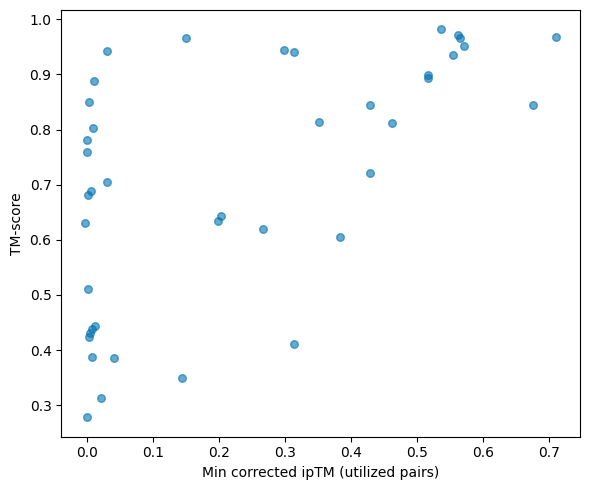

In [16]:
plot_df = (
    benchmark_best_cp_bigger
    .with_columns(
        pl.col("chain_pair_iptm_corrected").list.min().alias("min_iptm_corrected")
    )
    .select("min_iptm_corrected", "usalign_cpx_tm_score", "complex_ac", "chain_pair_pae_min")
    .drop_nulls()
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    plot_df["min_iptm_corrected"],
    plot_df["usalign_cpx_tm_score"],
    alpha=0.6, s=30, color="#0072B2"
)
ax.set_xlabel("Min corrected ipTM (utilized pairs)")
ax.set_ylabel("TM-score")
plt.tight_layout()
plt.show()

In [14]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

pdf = (
    plot_df
    .with_columns(pl.col("chain_pair_pae_min").list.min().alias("min_pae"))
    .to_pandas()
)

fig = make_subplots(rows=1, cols=2, shared_yaxes=True,
                    subplot_titles=["Min corrected ipTM", "Min PAE"])

common = dict(mode="markers", marker=dict(size=8, opacity=0.6),
              text=pdf["complex_ac"], hovertemplate="%{text}<extra></extra>")

fig.add_trace(go.Scatter(x=pdf["min_iptm_corrected"], y=pdf["usalign_cpx_tm_score"],
                         marker_color="#0072B2", **common), row=1, col=1)

fig.add_trace(go.Scatter(x=pdf["min_pae"], y=pdf["usalign_cpx_tm_score"],
                         marker_color="#E69F00", **common), row=1, col=2)

fig.update_xaxes(title_text="Min corrected ipTM (utilized pairs)", row=1, col=1)
fig.update_xaxes(title_text="Min PAE (utilized pairs)", row=1, col=2)
fig.update_yaxes(title_text="TM-score", row=1, col=1)
fig.update_layout(width=1000, height=500, showlegend=False)
fig.show()

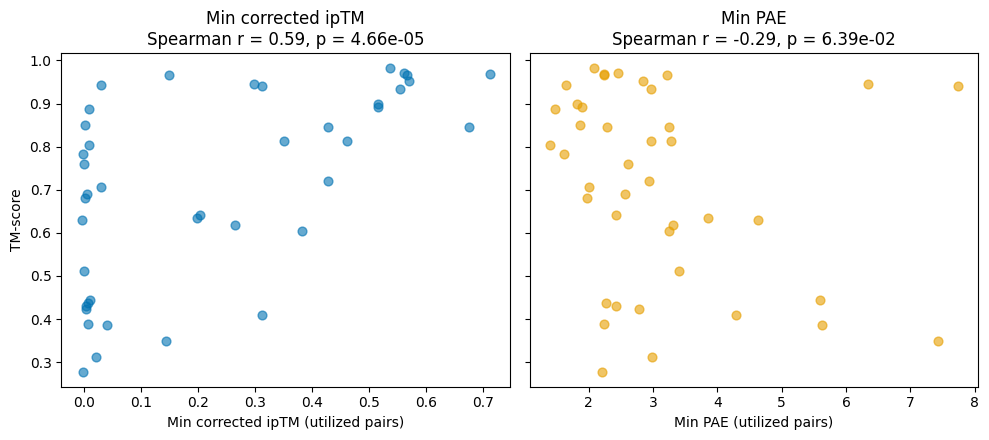

In [15]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

r_iptm, p_iptm = spearmanr(pdf["min_iptm_corrected"], pdf["usalign_cpx_tm_score"])
r_pae,  p_pae  = spearmanr(pdf["min_pae"],             pdf["usalign_cpx_tm_score"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

axes[0].scatter(pdf["min_iptm_corrected"], pdf["usalign_cpx_tm_score"],
                color="#0072B2", alpha=0.6, s=40)
axes[0].set_xlabel("Min corrected ipTM (utilized pairs)")
axes[0].set_ylabel("TM-score")
axes[0].set_title(f"Min corrected ipTM\nSpearman r = {r_iptm:.2f}, p = {p_iptm:.2e}")

axes[1].scatter(pdf["min_pae"], pdf["usalign_cpx_tm_score"],
                color="#E69F00", alpha=0.6, s=40)
axes[1].set_xlabel("Min PAE (utilized pairs)")
axes[1].set_title(f"Min PAE\nSpearman r = {r_pae:.2f}, p = {p_pae:.2e}")

plt.tight_layout()
plt.show()

In [11]:
# Paste the actual combfold_output_path for the homo-multimer (idx=3, npdb=4)
homo_path = (
    benchmark_best_cp_bigger
    .filter(pl.col("has_homomeric") | (pl.col("n_proteins") == 4))  # adjust filter
    .filter(pl.col("combfold_output_path").str.contains("output_clustered_3"))
    ["combfold_output_path"]
    .to_list()[0]
)

pdb = Path(homo_path)
asmdir = pdb.parent.parent / "_unified_representation" / "assembly_output"
raw = [l for l in (asmdir / "output_clustered.res").read_text().splitlines() if l.strip()][3]

# Show the foldSteps section in full
fs_match = re.search(r"foldSteps: (.+)$", raw)
pairs_raw = re.findall(r"\((\d+), (\d+)\)", fs_match.group(1))
cl_lines = (asmdir / "chain.list").read_text().strip().splitlines()
idx_to_up = {i: Path(l.strip()).stem.split("_")[0] for i, l in enumerate(cl_lines)}

print("chain.list:")
for i, l in enumerate(cl_lines):
    print(f"  [{i}] {l}")
print(f"\nfoldSteps pairs (raw indices): {pairs_raw}")
print(f"foldSteps pairs (UniProt):     {[(idx_to_up[int(a)], idx_to_up[int(b)]) for a,b in pairs_raw]}")
print(f"\nAfter de-duplication: {sorted({'_'.join(sorted([idx_to_up[int(a)], idx_to_up[int(b)]])) for a,b in pairs_raw})}")
print(f"\nExpected: 3 raw pairs all mapping to same UniProt → collapses to 1 string")

ColumnNotFoundError: unable to find column "has_homomeric"; valid columns: ["row_id", "complex_ac", "identifiers", "n_proteins", "pdb_id", "reference_pdb_model", "CP_stochiometry", "Combfold_result_path", "n_pairs_used", "pairs_used", "correct_pred_rank", "n_combfold_outputs", "reference_pdb_path", "combfold_output_path", "chain_mapping", "usalign_stdout_path", "usalign_pred_dir", "usalign_cpx_len_structure1", "usalign_cpx_len_structure2", "usalign_cpx_aligned_length", "usalign_cpx_rmsd", "usalign_cpx_seq_id", "usalign_cpx_tm_score", "usalign_per_chain_ID", "usalign_per_chain_len_structure1", "usalign_per_chain_len_structure2", "usalign_per_chain_aligned_length", "usalign_per_chain_rmsd", "usalign_per_chain_seq_id", "usalign_per_chain_tm_score", "cf_close_by_chainpairs", "ref_close_by_chainpairs", "exact_pdb_in_stoic", "pdb_with_identical_proteins_set_to_CF_in_stoic", "CF_confidence", "foldstep_pairs", "n_foldstep_pairs", "af_pairs", "chain_pair_iptm", "chain_pair_iptm_corrected", "cha

In [7]:
t = pl.read_csv("/cluster/project/beltrao/kdammer/master_thesis/data/Pipeline/10_all_CP_complexes/10_all_CP_complexes_pool_pairs_metrics_with_plddt_corrected.csv")

In [9]:
t.columns

['complex_ac',
 'protein1',
 'protein2',
 'pair',
 'pair_type',
 'af3_id1',
 'af3_id2',
 'chain_id1',
 'chain_id2',
 'input_name',
 'input_type',
 'batch_id',
 'seed',
 'sample',
 'ranking_score',
 'chain_pair_iptm',
 'chain_pair_pae_min',
 'chain_pair_pae_min_recap',
 'plddt1',
 'plddt2',
 'chain_pair_iptm_corrected']

In [12]:
t = t.select(['complex_ac','protein1','protein2','chain_pair_iptm_corrected'])
t = t.filter(pl.col('complex_ac')== "CPX-2662")